# Exploratory Data Analysis - Bank Marketing Dataset

## Project Overview

This notebook performs comprehensive **Exploratory Data Analysis (EDA)** on the UCI Bank Marketing dataset. The primary goal is to analyze marketing campaign data and understand patterns that could help predict whether a client will subscribe to a term deposit.

### Dataset Information
- **Dataset**: UCI Bank Marketing Dataset
- **Task**: Binary Classification (Yes/No subscription prediction)
- **Instances**: 45,211 (`bank-full.csv`)
- **Features**: 16 input variables + 1 target variable (`y`)

### Analysis Sections
1. Data Loading and Basic Information
2. Class Imbalance Analysis
3. Categorical Conversion Rate Analysis
4. Numerical Variables & Outliers Analysis
5. Correlation Heatmap
6. Seasonality Analysis
7. Duration Analysis

---


In [1]:
# Imports and Setup
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import yaml

# Add project root to path
# Assuming notebook is run from project root (typical Jupyter behavior)
# If run from notebooks/ directory, go up one level
current_dir = Path.cwd()
if current_dir.name == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir
sys.path.insert(0, str(project_root))

# Import EDA modules
from src.eda.data_loader import load_data, get_data_info, load_config
from src.eda.visualizations import (
    plot_class_imbalance,
    plot_categorical_conversion,
    plot_numerical_analysis,
    plot_correlation_heatmap,
    plot_seasonality,
    plot_duration_analysis
)

# Configure matplotlib for inline display
%matplotlib inline

# Set up plotting style
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 10

print("Setup complete! All modules imported successfully.")


Setup complete! All modules imported successfully.


In [2]:
# Load Configuration
config_path = "config/config.yaml"
config = load_config(config_path)

print("Configuration loaded successfully!")
print(f"\nData path: {config['data']['raw']}")
print(f"Delimiter: {config['data']['delimiter']}")
print(f"Output figures directory: {config['output']['figures_dir']}")
print(f"\nNumerical variables: {config['eda']['numerical_vars']}")
print(f"Categorical variables: {config['eda']['categorical_vars']}")
print(f"Target variable: {config['eda']['target_var']}")


Configuration loaded successfully!

Data path: data/raw/bank/bank-full.csv
Delimiter: ;
Output figures directory: reports/figures

Numerical variables: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical variables: ['job', 'marital', 'education']
Target variable: y


## 1. Data Loading and Basic Information

In this section, we load the dataset and examine its basic structure, including shape, data types, and summary statistics.


In [3]:
# Load the dataset
df = load_data(config_path=config_path)

# Get dataset information
data_info = get_data_info(df)

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset shape: {data_info['shape']}")
print(f"Number of rows: {data_info['shape'][0]:,}")
print(f"Number of columns: {data_info['shape'][1]}")

print("\n" + "=" * 80)
print("FIRST FEW ROWS")
print("=" * 80)
df.head()


DATASET OVERVIEW

Dataset shape: (45211, 17)
Number of rows: 45,211
Number of columns: 17

FIRST FEW ROWS


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# Dataset information
print("=" * 80)
print("DATASET INFO")
print("=" * 80)
df.info()


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
# Basic statistics
print("=" * 80)
print("BASIC STATISTICS")
print("=" * 80)
df.describe()


BASIC STATISTICS


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## 2. Class Imbalance Analysis

Analyzing the distribution of the target variable to understand class imbalance, which is crucial for model training and evaluation.


[OK] Saved: d:\workspaces\kntu\AI-FinalProject-MHM-POWER\reports\figures\class_imbalance_analysis.png


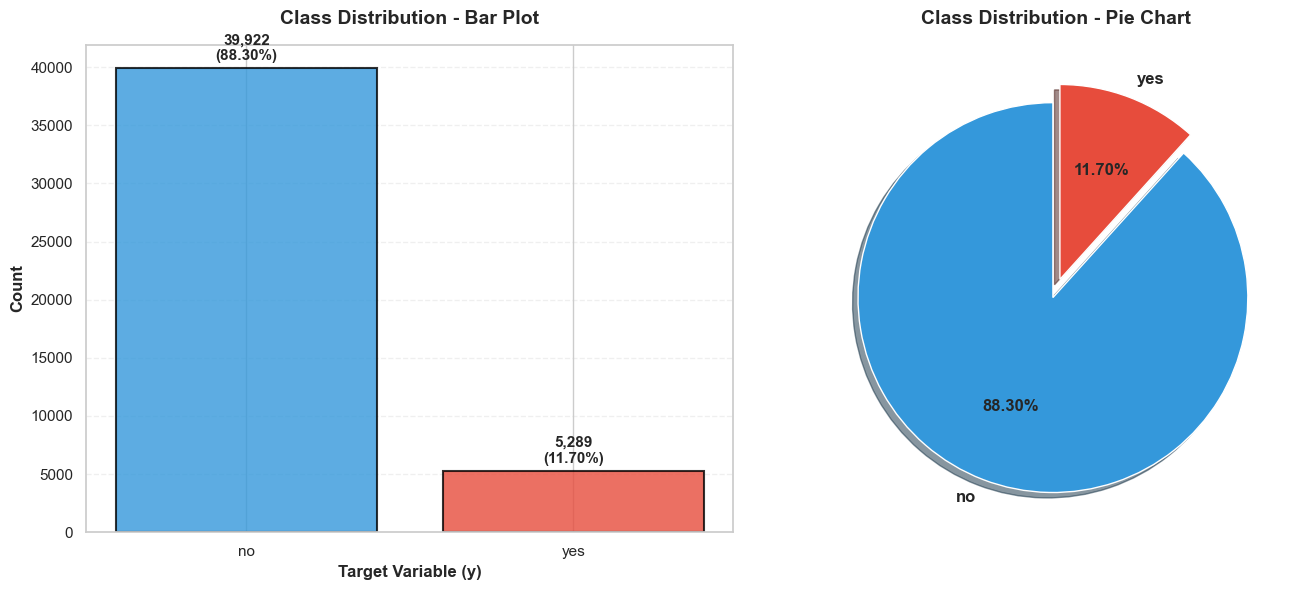


Target variable distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentages:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [6]:
# Class Imbalance Analysis
# Note: We'll create a version that displays inline
target_counts, target_percentages = plot_class_imbalance(df, config_path=config_path, save=True)

# Display inline version
target_var = config['eda']['target_var']
target_counts = df[target_var].value_counts()
target_percentages = df[target_var].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot
ax1 = axes[0]
bars = ax1.bar(target_counts.index, target_counts.values, 
               color=['#3498db', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Target Variable (y)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Class Distribution - Bar Plot', fontsize=14, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (idx, val) in enumerate(target_counts.items()):
    ax1.text(i, val + target_counts.max() * 0.01, 
             f'{val:,}\n({target_percentages[idx]:.2f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
ax2 = axes[1]
colors = ['#3498db', '#e74c3c']
wedges, texts, autotexts = ax2.pie(target_counts.values, 
                                    labels=target_counts.index,
                                    autopct='%1.2f%%',
                                    colors=colors,
                                    startangle=90,
                                    explode=(0.05, 0.05),
                                    shadow=True,
                                    textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Class Distribution - Pie Chart', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print(f"\nTarget variable distribution:")
print(target_counts)
print(f"\nPercentages:")
print(target_percentages)


## 3. Categorical Conversion Rate Analysis

Examining how different categorical variables (job, marital status, education) relate to subscription conversion rates.


[OK] Saved: d:\workspaces\kntu\AI-FinalProject-MHM-POWER\reports\figures\categorical_conversion_rate.png


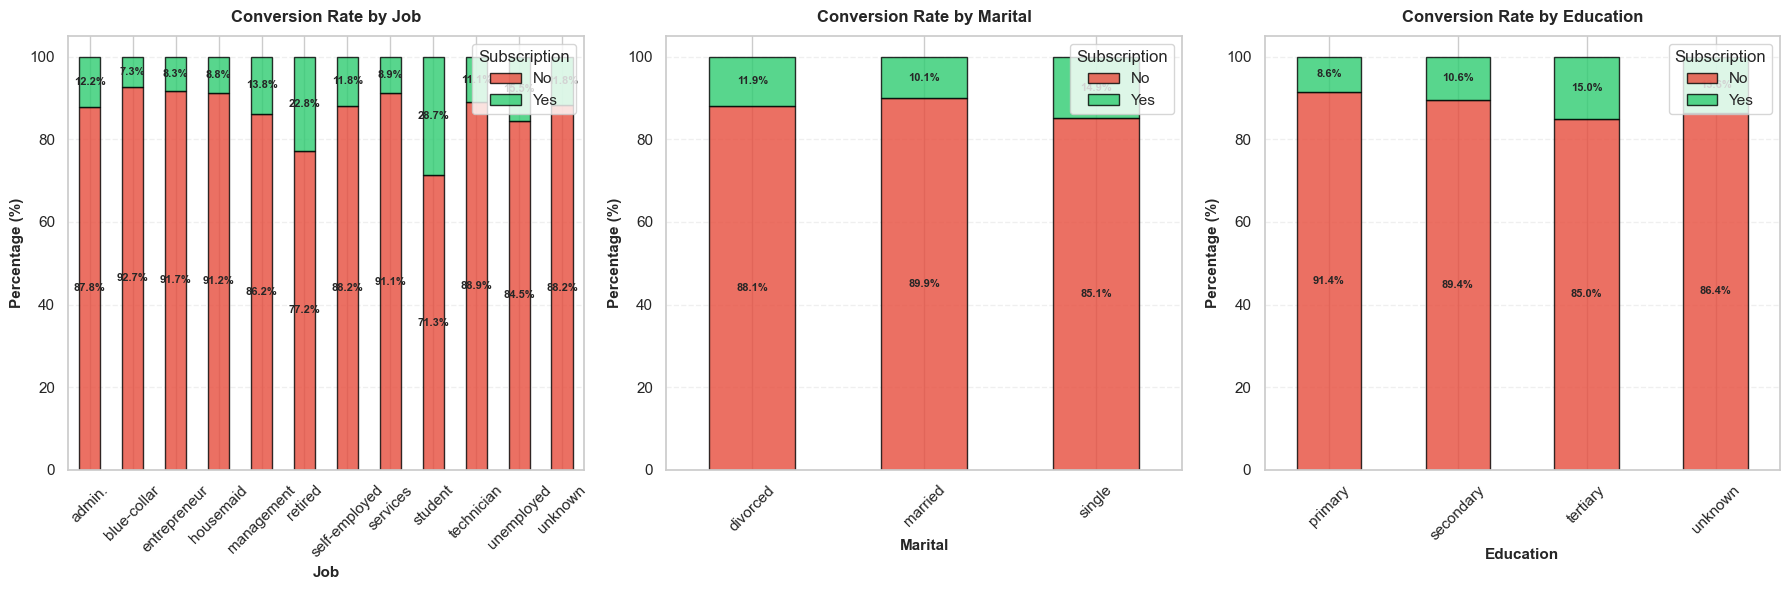

In [7]:
# Categorical Conversion Rate Analysis
plot_categorical_conversion(df, config_path=config_path, save=True)

# Display inline version
categorical_vars = config['eda']['categorical_vars']
target_var = config['eda']['target_var']

fig, axes = plt.subplots(1, len(categorical_vars), figsize=(18, 6))

for idx, var in enumerate(categorical_vars):
    ax = axes[idx] if len(categorical_vars) > 1 else axes
    
    # Create crosstab for stacked bar plot
    crosstab = pd.crosstab(df[var], df[target_var], normalize='index') * 100
    
    # Plot stacked bar
    crosstab.plot(kind='bar', stacked=True, ax=ax, 
                  color=['#e74c3c', '#2ecc71'], alpha=0.8, edgecolor='black', linewidth=1)
    
    ax.set_xlabel(var.capitalize(), fontsize=11, fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
    ax.set_title(f'Conversion Rate by {var.capitalize()}', fontsize=12, fontweight='bold', pad=10)
    ax.legend(title='Subscription', labels=['No', 'Yes'], loc='upper right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=45)
    
    # Add percentage annotations
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Numerical Variables & Outliers Analysis

Analyzing numerical variables (age, balance) to understand distributions and identify outliers that might affect model performance.



Balance Outlier Statistics:
  Q1: 72.00
  Q3: 1428.00
  IQR: 1356.00
  Lower bound: -1962.00
  Upper bound: 3462.00
  Number of outliers: 4729 (10.46%)
[OK] Saved: d:\workspaces\kntu\AI-FinalProject-MHM-POWER\reports\figures\numerical_outliers_analysis.png


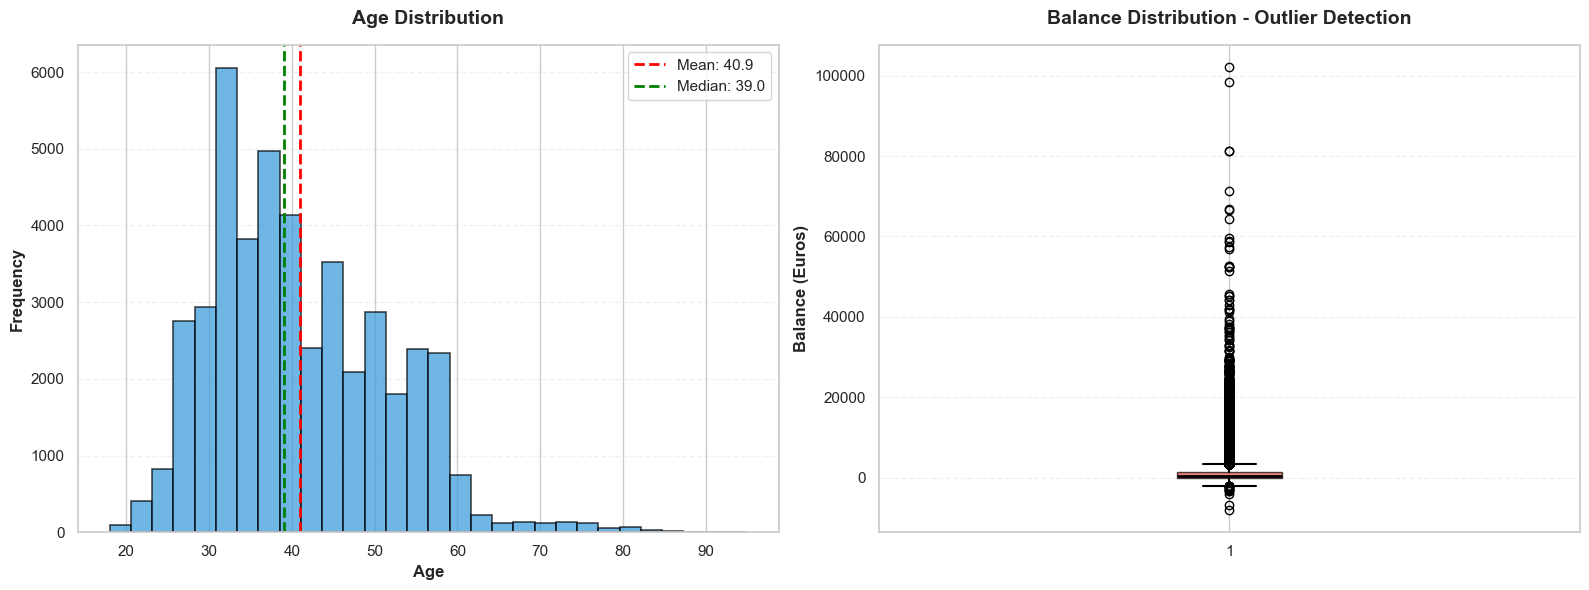


Balance Outlier Statistics:
  Q1: 72.00
  Q3: 1428.00
  IQR: 1356.00
  Lower bound: -1962.00
  Upper bound: 3462.00
  Number of outliers: 4729 (10.46%)


In [8]:
# Numerical Variables & Outliers Analysis
outlier_stats = plot_numerical_analysis(df, config_path=config_path, save=True)

# Display inline version
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for age
ax1 = axes[0]
ax1.hist(df['age'], bins=30, color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.2)
ax1.set_xlabel('Age', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Age Distribution', fontsize=14, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {df["age"].mean():.1f}')
ax1.axvline(df['age'].median(), color='green', linestyle='--', linewidth=2, 
            label=f'Median: {df["age"].median():.1f}')
ax1.legend()

# Boxplot for balance
ax2 = axes[1]
box_plot = ax2.boxplot(df['balance'], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#e74c3c', alpha=0.7),
                       medianprops=dict(color='black', linewidth=2),
                       whiskerprops=dict(color='black', linewidth=1.5),
                       capprops=dict(color='black', linewidth=1.5))
ax2.set_ylabel('Balance (Euros)', fontsize=12, fontweight='bold')
ax2.set_title('Balance Distribution - Outlier Detection', fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Display outlier statistics
print("\nBalance Outlier Statistics:")
print(f"  Q1: {outlier_stats['Q1']:.2f}")
print(f"  Q3: {outlier_stats['Q3']:.2f}")
print(f"  IQR: {outlier_stats['IQR']:.2f}")
print(f"  Lower bound: {outlier_stats['lower_bound']:.2f}")
print(f"  Upper bound: {outlier_stats['upper_bound']:.2f}")
print(f"  Number of outliers: {outlier_stats['outlier_count']} ({outlier_stats['outlier_percentage']:.2f}%)")


## 5. Correlation Heatmap

Examining correlations between numerical variables to identify multicollinearity and relationships that could inform feature selection.



Correlation Matrix:
            age  balance    day  duration  campaign  pdays  previous
age       1.000    0.098 -0.009    -0.005     0.005 -0.024     0.001
balance   0.098    1.000  0.005     0.022    -0.015  0.003     0.017
day      -0.009    0.005  1.000    -0.030     0.162 -0.093    -0.052
duration -0.005    0.022 -0.030     1.000    -0.085 -0.002     0.001
campaign  0.005   -0.015  0.162    -0.085     1.000 -0.089    -0.033
pdays    -0.024    0.003 -0.093    -0.002    -0.089  1.000     0.455
previous  0.001    0.017 -0.052     0.001    -0.033  0.455     1.000
[OK] Saved: d:\workspaces\kntu\AI-FinalProject-MHM-POWER\reports\figures\correlation_heatmap.png

Correlation Matrix:
            age  balance    day  duration  campaign  pdays  previous
age       1.000    0.098 -0.009    -0.005     0.005 -0.024     0.001
balance   0.098    1.000  0.005     0.022    -0.015  0.003     0.017
day      -0.009    0.005  1.000    -0.030     0.162 -0.093    -0.052
duration -0.005    0.022 -0.030  

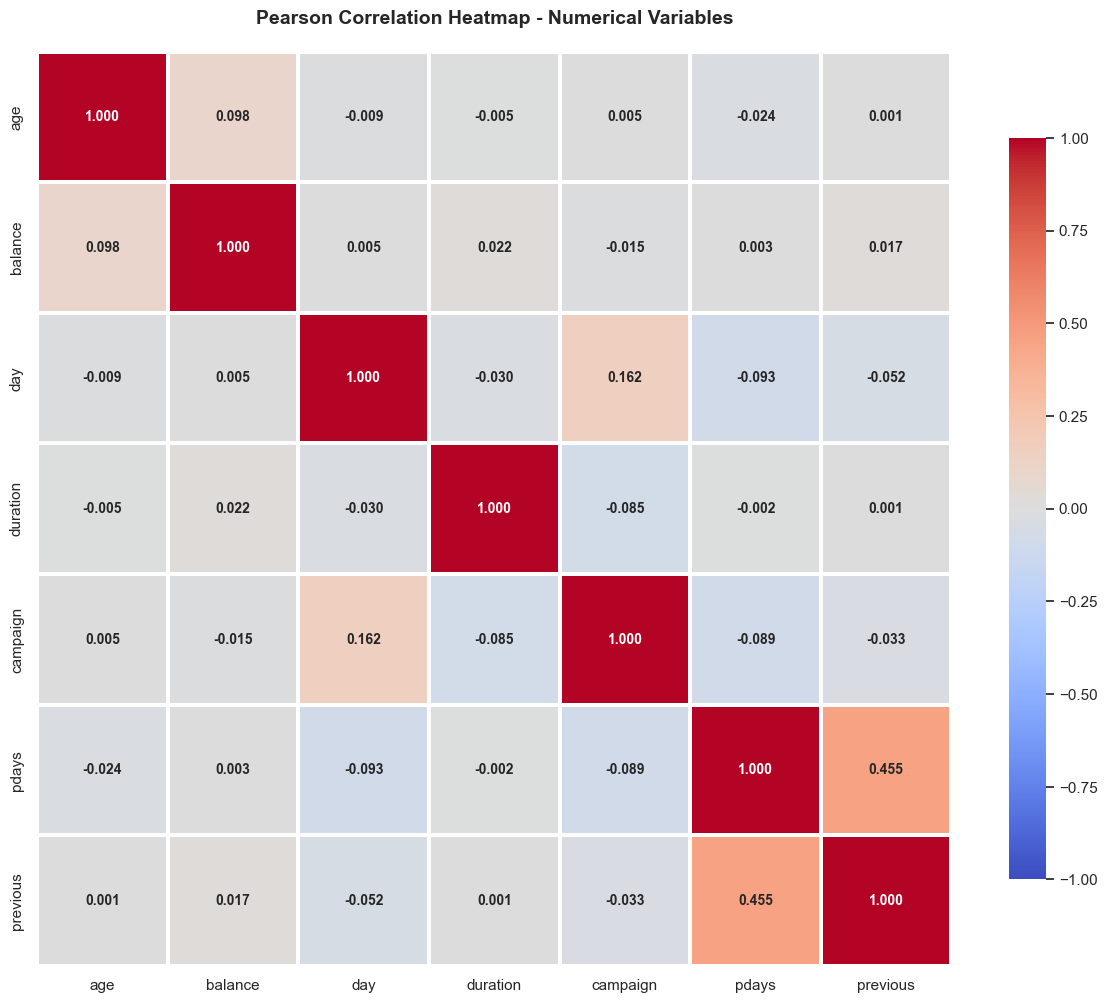

In [9]:
# Correlation Heatmap
correlation_matrix = plot_correlation_heatmap(df, config_path=config_path, save=True)

# Display inline version
numerical_vars = config['eda']['numerical_vars']
numerical_df = df[numerical_vars]
correlation_matrix = numerical_df.corr(method='pearson')

print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, annot_kws={'fontsize': 10, 'fontweight': 'bold'})
plt.title('Pearson Correlation Heatmap - Numerical Variables', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


## 6. Seasonality Analysis

Analyzing monthly trends to identify seasonal patterns in subscription success rates that could inform campaign timing.



Monthly Success Rates:
month  total  yes_count  success_rate
  jan   1403        142     10.121169
  feb   2649        441     16.647792
  mar    477        248     51.991614
  apr   2932        577     19.679400
  may  13766        925      6.719454
  jun   5341        546     10.222805
  jul   6895        627      9.093546
  aug   6247        688     11.013286
  sep    579        269     46.459413
  oct    738        323     43.766938
  nov   3970        403     10.151134
  dec    214        100     46.728972
[OK] Saved: d:\workspaces\kntu\AI-FinalProject-MHM-POWER\reports\figures\seasonality_analysis.png

Monthly Success Rates:
month  total  yes_count  success_rate
  jan   1403        142     10.121169
  feb   2649        441     16.647792
  mar    477        248     51.991614
  apr   2932        577     19.679400
  may  13766        925      6.719454
  jun   5341        546     10.222805
  jul   6895        627      9.093546
  aug   6247        688     11.013286
  sep    579      

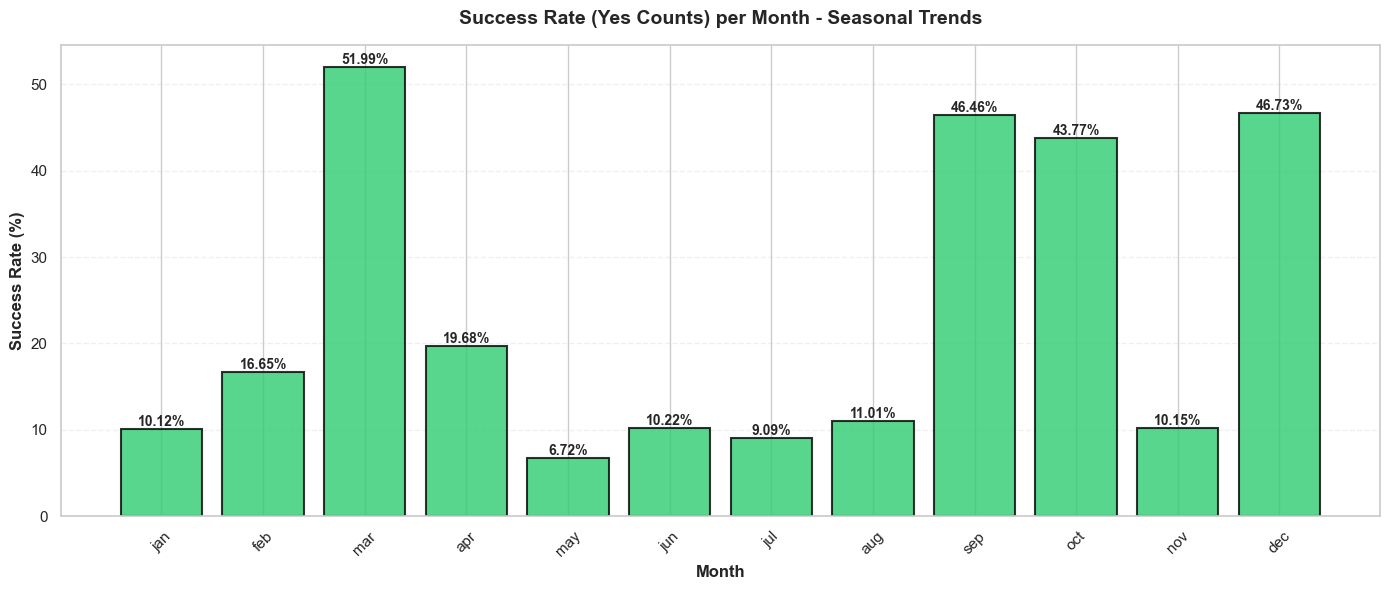

In [10]:
# Seasonality Analysis
monthly_stats = plot_seasonality(df, config_path=config_path, save=True)

# Display inline version
target_var = config['eda']['target_var']

# Calculate success rate per month
monthly_stats = df.groupby('month')[target_var].agg(['count', lambda x: (x == 'yes').sum()]).reset_index()
monthly_stats.columns = ['month', 'total', 'yes_count']
monthly_stats['success_rate'] = (monthly_stats['yes_count'] / monthly_stats['total']) * 100

# Order months chronologically
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
monthly_stats['month'] = pd.Categorical(monthly_stats['month'], categories=month_order, ordered=True)
monthly_stats = monthly_stats.sort_values('month')

print("\nMonthly Success Rates:")
print(monthly_stats[['month', 'total', 'yes_count', 'success_rate']].to_string(index=False))

plt.figure(figsize=(14, 6))
bars = plt.bar(monthly_stats['month'], monthly_stats['success_rate'], 
               color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.5)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
plt.title('Success Rate (Yes Counts) per Month - Seasonal Trends', 
          fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, rate in zip(bars, monthly_stats['success_rate']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{rate:.2f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Duration Analysis

Analyzing call duration patterns and their relationship with subscription outcomes. **Important**: This analysis is for understanding patterns only - duration should NOT be used as a feature in predictive models.


[OK] Saved: d:\workspaces\kntu\AI-FinalProject-MHM-POWER\reports\figures\duration_analysis.png

Duration Statistics:
  No - Mean: 221.18s, Median: 164.00s
  Yes - Mean: 537.29s, Median: 426.00s


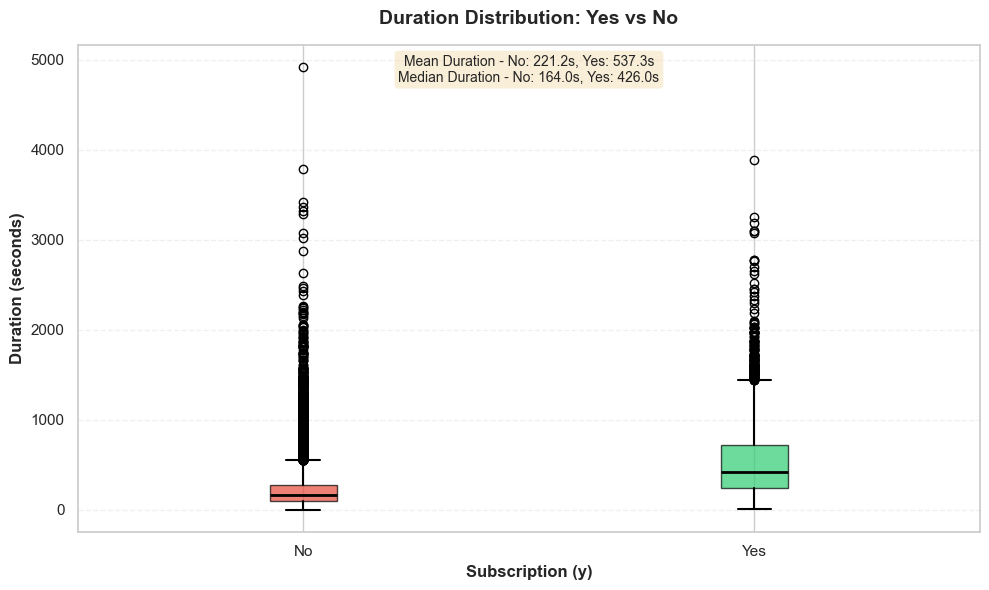


Duration Statistics:
  No - Mean: 221.18s, Median: 164.00s
  Yes - Mean: 537.29s, Median: 426.00s


In [11]:
# Duration Analysis
duration_stats = plot_duration_analysis(df, config_path=config_path, save=True)

# Display inline version
target_var = config['eda']['target_var']

# Prepare data for boxplot
duration_yes = df[df[target_var] == 'yes']['duration']
duration_no = df[df[target_var] == 'no']['duration']

fig, ax = plt.subplots(figsize=(10, 6))

box_data = [duration_no, duration_yes]
box_plot = ax.boxplot(box_data, tick_labels=['No', 'Yes'], patch_artist=True,
                      boxprops=dict(facecolor='#e74c3c', alpha=0.7),
                      medianprops=dict(color='black', linewidth=2),
                      whiskerprops=dict(color='black', linewidth=1.5),
                      capprops=dict(color='black', linewidth=1.5))

# Change color for 'Yes' box
box_plot['boxes'][1].set_facecolor('#2ecc71')

ax.set_xlabel('Subscription (y)', fontsize=12, fontweight='bold')
ax.set_ylabel('Duration (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Duration Distribution: Yes vs No', fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add statistics text
stats_text = f"Mean Duration - No: {duration_no.mean():.1f}s, Yes: {duration_yes.mean():.1f}s\n"
stats_text += f"Median Duration - No: {duration_no.median():.1f}s, Yes: {duration_yes.median():.1f}s"
ax.text(0.5, 0.98, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', horizontalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print duration statistics
print("\nDuration Statistics:")
print(f"  No - Mean: {duration_no.mean():.2f}s, Median: {duration_no.median():.2f}s")
print(f"  Yes - Mean: {duration_yes.mean():.2f}s, Median: {duration_yes.median():.2f}s")


## ⚠️ DATA LEAKAGE WARNING - Duration Variable

### IMPORTANT: The 'duration' variable may cause DATA LEAKAGE in a real-world scenario.

**REASON:**
- Duration is the length of the last contact call (in seconds)
- This information is only available **AFTER** the call has been completed
- In a real-world prediction scenario, we need to predict **BEFORE** making the call
- Therefore, duration should **NOT** be used as a feature for model training
- Including it would give the model information it wouldn't have in production

**RECOMMENDATION:**
- Exclude 'duration' from feature engineering for the classification model
- Use it only for post-campaign analysis and understanding call patterns
- The preprocessing pipeline already handles this by removing the duration column


## EDA Summary

### Completed Analyses

✅ **Dataset Loading**: Successfully loaded 45,211 rows with 17 columns  
✅ **Class Imbalance Analysis**: Identified significant class imbalance in target variable  
✅ **Categorical Conversion Rates**: Analyzed conversion patterns across job, marital status, and education  
✅ **Numerical Variables & Outliers**: Examined age and balance distributions, identified outliers  
✅ **Correlation Heatmap**: Mapped relationships between numerical variables  
✅ **Seasonality Trends**: Identified monthly patterns in subscription success rates  
✅ **Duration Analysis**: Analyzed call duration patterns (with data leakage warning)  

### Generated Visualizations

All visualizations have been saved to `reports/figures/`:
- `class_imbalance_analysis.png` - Target variable distribution
- `categorical_conversion_rate.png` - Conversion rates by categorical variables
- `numerical_outliers_analysis.png` - Age and balance distributions
- `correlation_heatmap.png` - Correlation matrix
- `seasonality_analysis.png` - Monthly success rates
- `duration_analysis.png` - Duration patterns by subscription outcome

### Next Steps

1. **Data Preprocessing**: Clean and transform the data for modeling
2. **Feature Engineering**: Create new features based on EDA insights
3. **Model Training**: Train baseline and advanced models
4. **Model Evaluation**: Assess model performance on validation and test sets
